[List of U.S. states and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_life_expectancy) <i>([alternative design](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_U.S._states_and_territories_by_life_expectancy_(alternative)))</i> / [Продолжительность жизни в штатах США](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_штатах_США)<br>
Source: [National Center for Health Statistics](https://www.cdc.gov/nchs/fastats/life-expectancy.htm) (NCHS) - a unit of the CDC<br>
at [Wikipedia Commons](https://commons.wikimedia.org/wiki/User:Lady3mlnm#Life_expectancy_by_race_in_the_USA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from collections import namedtuple

In [3]:
LANG = 'en'
DESTINATION_OUTPUT = 'show'  # to where table code should be placed: 'file', 'show'

In [4]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'color', 'style', 'width', 'alpha'])

In [5]:
df = pd.read_csv('data/Life expectancy by race -2021.csv', delimiter='\t', index_col='Year', na_values='---')
df.index.name = ''

df.loc[:2000, :].fillna('')

,Population_all,Population_male,Population_female,Hispanic_all,Hispanic_male,Hispanic_female,Native_all,Native_male,Native_female,Asian_all,Asian_male,Asian_female,Black_all,Black_male,Black_female,White_all,White_male,White_female
,,,,,,,,,,,,,,,,,,
2021,76.4,73.5,79.3,77.8,74.6,81.1,65.6,62.2,69.2,83.5,81.2,85.6,71.2,67.6,75.0,76.7,74.0,79.5
2020,77.0,74.2,79.9,77.9,74.6,81.3,67.1,63.8,70.7,83.6,81.1,85.9,71.5,67.8,75.4,77.4,74.8,80.1
2019,78.8,76.3,81.4,81.9,79.1,84.4,71.8,68.6,75.0,85.6,83.5,87.4,74.8,71.3,78.1,78.8,76.3,81.3
2018,78.7,76.2,81.2,81.8,79.1,84.3,,,,,,,74.7,71.3,78.0,78.6,76.2,81.1
2017,78.6,76.1,81.1,81.8,79.1,84.3,,,,,,,74.9,71.5,78.1,78.5,76.1,81.0
2016,78.7,76.2,81.1,81.8,79.1,84.3,,,,,,,74.9,71.6,78.0,78.6,76.2,81.0
2015,78.7,76.3,81.1,81.9,79.3,84.3,,,,,,,75.1,71.9,78.1,78.7,76.3,81.0
2014,78.9,76.5,81.3,82.1,79.4,84.5,,,,,,,75.3,72.2,78.2,78.8,76.5,81.2
2013,78.8,76.4,81.2,81.9,79.2,84.2,,,,,,,75.1,71.9,78.1,78.8,76.5,81.2


In [6]:
# delete columns that contains less than 3 n/a values
df.dropna(axis='columns', thresh=3, inplace=True)

# delete years for those there are less than 4 n/a values
df.dropna(axis='index', thresh=4, inplace=True)

df.loc[:2000, :].fillna('')

,Population_all,Population_male,Population_female,Hispanic_all,Hispanic_male,Hispanic_female,Native_all,Native_male,Native_female,Asian_all,Asian_male,Asian_female,Black_all,Black_male,Black_female,White_all,White_male,White_female
,,,,,,,,,,,,,,,,,,
2021,76.4,73.5,79.3,77.8,74.6,81.1,65.6,62.2,69.2,83.5,81.2,85.6,71.2,67.6,75.0,76.7,74.0,79.5
2020,77.0,74.2,79.9,77.9,74.6,81.3,67.1,63.8,70.7,83.6,81.1,85.9,71.5,67.8,75.4,77.4,74.8,80.1
2019,78.8,76.3,81.4,81.9,79.1,84.4,71.8,68.6,75.0,85.6,83.5,87.4,74.8,71.3,78.1,78.8,76.3,81.3
2018,78.7,76.2,81.2,81.8,79.1,84.3,,,,,,,74.7,71.3,78.0,78.6,76.2,81.1
2017,78.6,76.1,81.1,81.8,79.1,84.3,,,,,,,74.9,71.5,78.1,78.5,76.1,81.0
2016,78.7,76.2,81.1,81.8,79.1,84.3,,,,,,,74.9,71.6,78.0,78.6,76.2,81.0
2015,78.7,76.3,81.1,81.9,79.3,84.3,,,,,,,75.1,71.9,78.1,78.7,76.3,81.0
2014,78.9,76.5,81.3,82.1,79.4,84.5,,,,,,,75.3,72.2,78.2,78.8,76.5,81.2
2013,78.8,76.4,81.2,81.9,79.2,84.2,,,,,,,75.1,71.9,78.1,78.8,76.5,81.2


In [7]:
df = df.loc[:, ['Population_female', 'Population_all', 'Population_male',
                'Black_female', 'Black_all', 'Black_male',
                'White_female', 'White_all', 'White_male',
                'Hispanic_female', 'Hispanic_all', 'Hispanic_male']]

df.insert(loc= 3, column='Population_fΔm', value=(df['Population_female']-df['Population_male']).round(1))
df.insert(loc= 7, column='Black_fΔm',      value=(df['Black_female']     -df['Black_male'])     .round(1))
df.insert(loc=11, column='White_fΔm',      value=(df['White_female']     -df['White_male'])     .round(1))
df.insert(loc=15, column='Hispanic_fΔm',   value=(df['Hispanic_female']  -df['Hispanic_male'])  .round(1))

df

,Population_female,Population_all,Population_male,Population_fΔm,Black_female,Black_all,Black_male,Black_fΔm,White_female,White_all,White_male,White_fΔm,Hispanic_female,Hispanic_all,Hispanic_male,Hispanic_fΔm
,,,,,,,,,,,,,,,,
2021,79.3,76.4,73.5,5.8,75.0,71.2,67.6,7.4,79.5,76.7,74.0,5.5,81.1,77.8,74.6,6.5
2020,79.9,77.0,74.2,5.7,75.4,71.5,67.8,7.6,80.1,77.4,74.8,5.3,81.3,77.9,74.6,6.7
2019,81.4,78.8,76.3,5.1,78.1,74.8,71.3,6.8,81.3,78.8,76.3,5.0,84.4,81.9,79.1,5.3
2018,81.2,78.7,76.2,5.0,78.0,74.7,71.3,6.7,81.1,78.6,76.2,4.9,84.3,81.8,79.1,5.2
2017,81.1,78.6,76.1,5.0,78.1,74.9,71.5,6.6,81.0,78.5,76.1,4.9,84.3,81.8,79.1,5.2
2016,81.1,78.7,76.2,4.9,78.0,74.9,71.6,6.4,81.0,78.6,76.2,4.8,84.3,81.8,79.1,5.2
2015,81.1,78.7,76.3,4.8,78.1,75.1,71.9,6.2,81.0,78.7,76.3,4.7,84.3,81.9,79.3,5.0
2014,81.3,78.9,76.5,4.8,78.2,75.3,72.2,6.0,81.2,78.8,76.5,4.7,84.5,82.1,79.4,5.1
2013,81.2,78.8,76.4,4.8,78.1,75.1,71.9,6.2,81.2,78.8,76.5,4.7,84.2,81.9,79.2,5.0


In [8]:
# transform dataframe
df = df.loc[::-1].T
df

,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Population_female,80.3,80.6,80.6,80.9,81.0,81.1,81.2,81.2,81.3,81.1,81.1,81.1,81.2,81.4,79.9,79.3
Population_all,77.8,78.1,78.2,78.5,78.7,78.7,78.8,78.8,78.9,78.7,78.7,78.6,78.7,78.8,77.0,76.4
Population_male,75.2,75.5,75.6,76.0,76.2,76.3,76.4,76.4,76.5,76.3,76.2,76.1,76.2,76.3,74.2,73.5
Population_fΔm,5.1,5.1,5.0,4.9,4.8,4.8,4.8,4.8,4.8,4.8,4.9,5.0,5.0,5.1,5.7,5.8
Black_female,76.4,76.7,77.0,77.4,77.7,77.8,78.1,78.1,78.2,78.1,78.0,78.1,78.0,78.1,75.4,75.0
Black_all,73.1,73.5,73.9,74.4,74.7,75.0,75.1,75.1,75.3,75.1,74.9,74.9,74.7,74.8,71.5,71.2
Black_male,69.5,69.9,70.5,71.0,71.5,71.8,71.9,71.9,72.2,71.9,71.6,71.5,71.3,71.3,67.8,67.6
Black_fΔm,6.9,6.8,6.5,6.4,6.2,6.0,6.2,6.2,6.0,6.2,6.4,6.6,6.7,6.8,7.6,7.4
White_female,80.6,80.8,80.7,81.0,81.1,81.1,81.2,81.2,81.2,81.0,81.0,81.0,81.1,81.3,80.1,79.5
White_all,78.2,78.4,78.4,78.7,78.8,78.7,78.9,78.8,78.8,78.7,78.6,78.5,78.6,78.8,77.4,76.7


In [9]:
dd_display = {
    'Population_female': DisplayedGroup(en_name=' ',                ru_name=' ',                         color='lightgrey', style=':',  width=6, alpha=0),
    'Population_all'   : DisplayedGroup(en_name='Population Overall', ru_name='в целом',                 color='lightgrey', style='-',  width=12, alpha=1),
    'Population_male'  : DisplayedGroup(en_name=' ',                ru_name=' ',                         color='lightgrey', style='--', width=6, alpha=0),
    'Population_fΔm'   : DisplayedGroup(en_name='Population sex gap', ru_name='Межполовая разница в целом', color='lightgrey', style='-', width=6, alpha=1),
    'Black_female'     : DisplayedGroup(en_name='Black Female',     ru_name='Афроамериканцы -женщины',   color='#444444', style=':',  width=2, alpha=1),
    'Black_all'        : DisplayedGroup(en_name='Black Overall',      ru_name='Афроамериканцы -в целом', color='#444444', style='-',  width=4, alpha=1),
    'Black_male'       : DisplayedGroup(en_name='Black Male',       ru_name='Афроамериканцы -мужчины',   color='#444444', style='--', width=2, alpha=1),
    'Black_fΔm'        : DisplayedGroup(en_name='Black sex gap',    ru_name='Межполовая разница для афроамериканцев', color='#444444', style='-', width=2.5, alpha=1),
    'White_female'     : DisplayedGroup(en_name='White Female',     ru_name='Белый -женщины',            color='blue', style=':',  width=2, alpha=1),
    'White_all'        : DisplayedGroup(en_name='White Overall',      ru_name='Белый -в целом',          color='blue', style='-',  width=4, alpha=1),
    'White_male'       : DisplayedGroup(en_name='White Male',       ru_name='Белый -мужчины',            color='blue', style='--', width=2, alpha=1),
    'White_fΔm'        : DisplayedGroup(en_name='White sex gap',    ru_name='Межполовая разница для белых', color='blue', style='-', width=2.5, alpha=1),
    'Hispanic_female'  : DisplayedGroup(en_name='Hispanic Female',  ru_name='Латиноамериканцы -женщины', color='red', style=':',  width=2, alpha=1),
    'Hispanic_all'     : DisplayedGroup(en_name='Hispanic Overall',   ru_name='Латиноамериканцы -в целом', color='red', style='-',  width=4, alpha=1),
    'Hispanic_male'    : DisplayedGroup(en_name='Hispanic Male',    ru_name='Латиноамериканцы -мужчины', color='red', style='--', width=2, alpha=1),
    'Hispanic_fΔm'     : DisplayedGroup(en_name='Hispanic sex gap', ru_name='Межполовая разница для латиноамериканцев', color='red', style='-', width=2.5, alpha=1), 
}

<br>

min value: 67.6
max value: 84.5


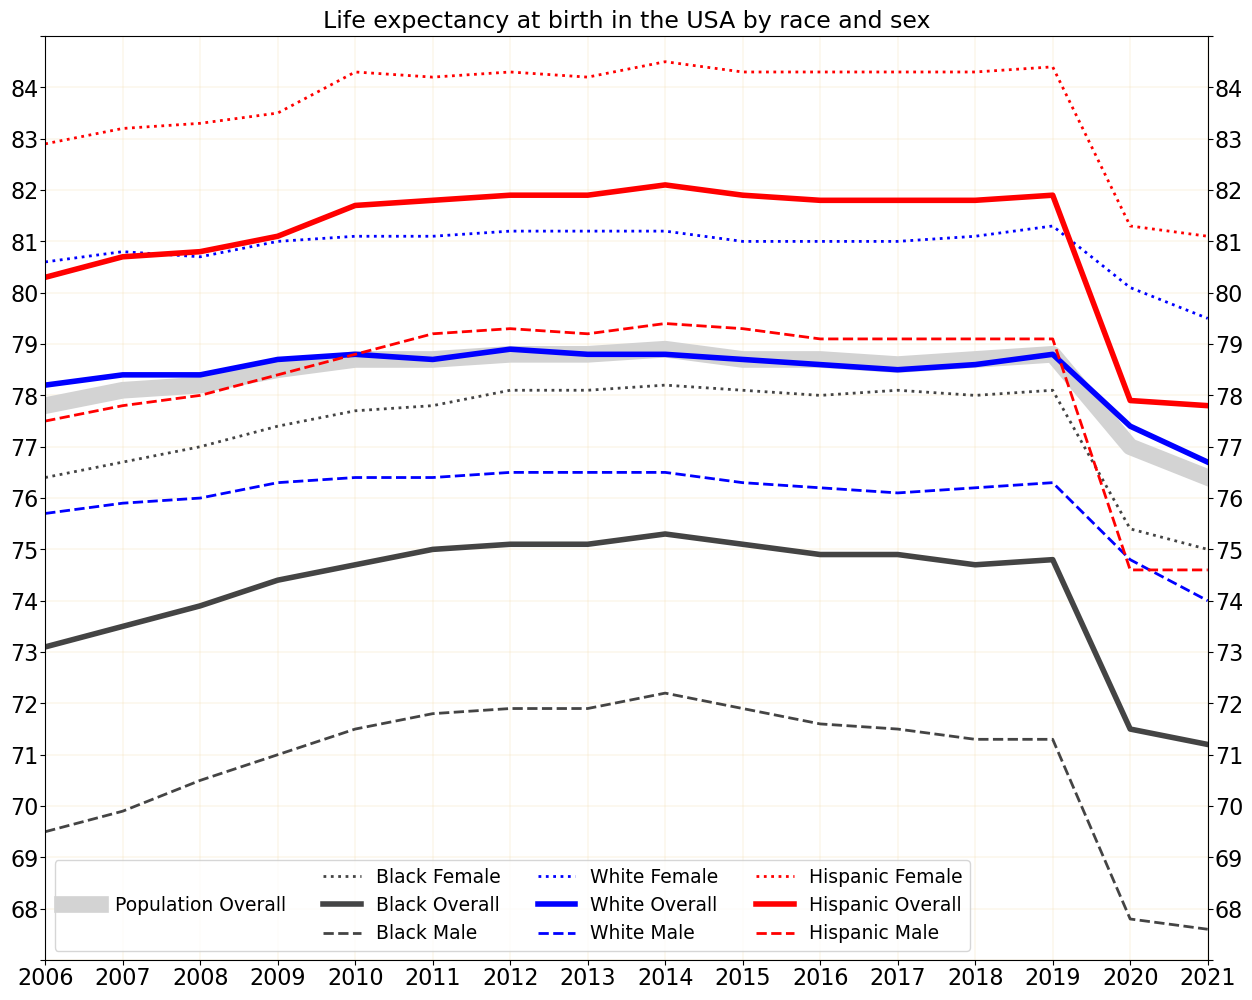

In [11]:
def create_chart(df, lang=LANG, dd_display=dd_display, ncol=4,
                 title_en='Life expectancy at birth in the USA by race and sex',
                 title_ru='Ожидаемая при рождении продолжительность жизни в США в зависимости от расы и пола',
                 destination=DESTINATION_OUTPUT, file_name=''
                ):
    
    plt.rcParams['figure.figsize'] = (16, 12.5) if lang=='ru' else (15, 12)
    
    year_min = df.columns[0]
    year_max = df.columns[-1]
    
    _ = df.min().min()
    print(f'min value: {_:.1f}')
    ylim_min = math.floor(_)
    
    _ = df.max().max()
    print(f'max value: {_:.1f}')
    ylim_max = math.ceil(_)
    
    plt.tick_params(axis='y', which='both', labelleft=True, labelright=True, reset=True, pad=1.5)
    plt.tick_params(axis='x', which='both', pad=1.5)

    plt.xlim(year_min, year_max)
    plt.ylim(ylim_min, ylim_max)
    
    labels_x = range(year_min, year_max+1)
    plt.xticks(labels_x, fontsize=16)
    
    labels_y = range(ylim_min, ylim_max+1)
    y_labels_names = ('',)  + tuple(labels_y)[1:-1] + ('',)
    plt.yticks(labels_y, labels=y_labels_names, fontsize=16)
    
    plt.grid(color='wheat', linewidth=0.3)
    
    plt.title(title_ru if lang=='ru' else title_en, fontsize=17)
    
    for gr in df.index.to_list():
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha)

    plt.legend(loc='lower left', fontsize=13.5, ncol=ncol)
    
    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()
    
create_chart(df.loc[['Population_female', 'Population_all', 'Population_male', 'Black_female', 'Black_all', 'Black_male',
                     'White_female', 'White_all', 'White_male', 'Hispanic_female', 'Hispanic_all', 'Hispanic_male']],
             file_name='Life expectancy in USA by race -all data', lang=LANG)

min value: 71.2
max value: 82.1


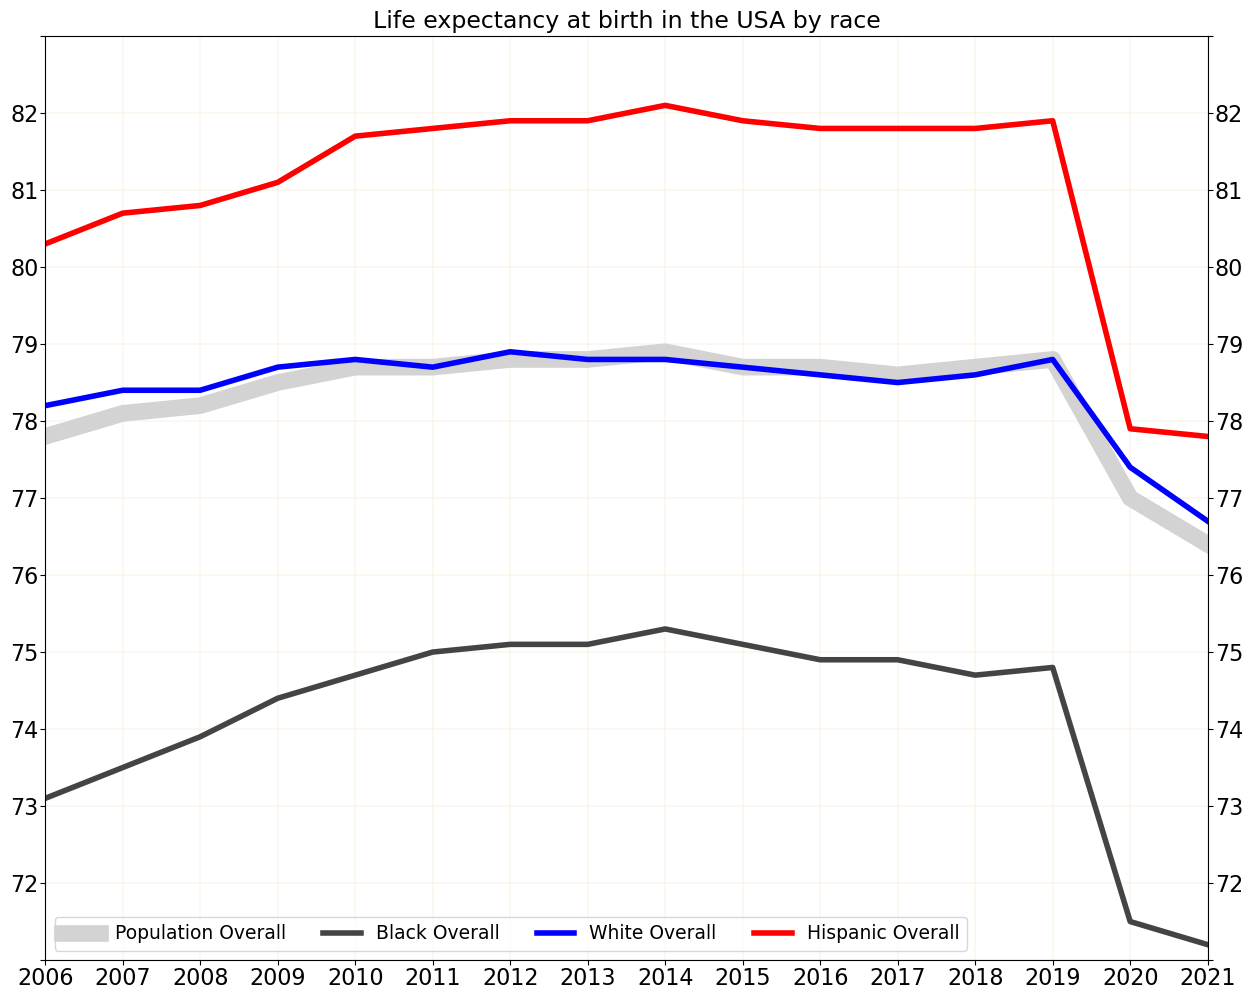

In [12]:
create_chart(df.loc[['Population_all', 'Black_all', 'White_all', 'Hispanic_all']],
             title_en='Life expectancy at birth in the USA by race',
             title_ru='Ожидаемая при рождении продолжительность жизни в США в зависимости от расы',
             file_name='Life expectancy in USA by race -only overall', lang=LANG)

min value: 67.6
max value: 84.5


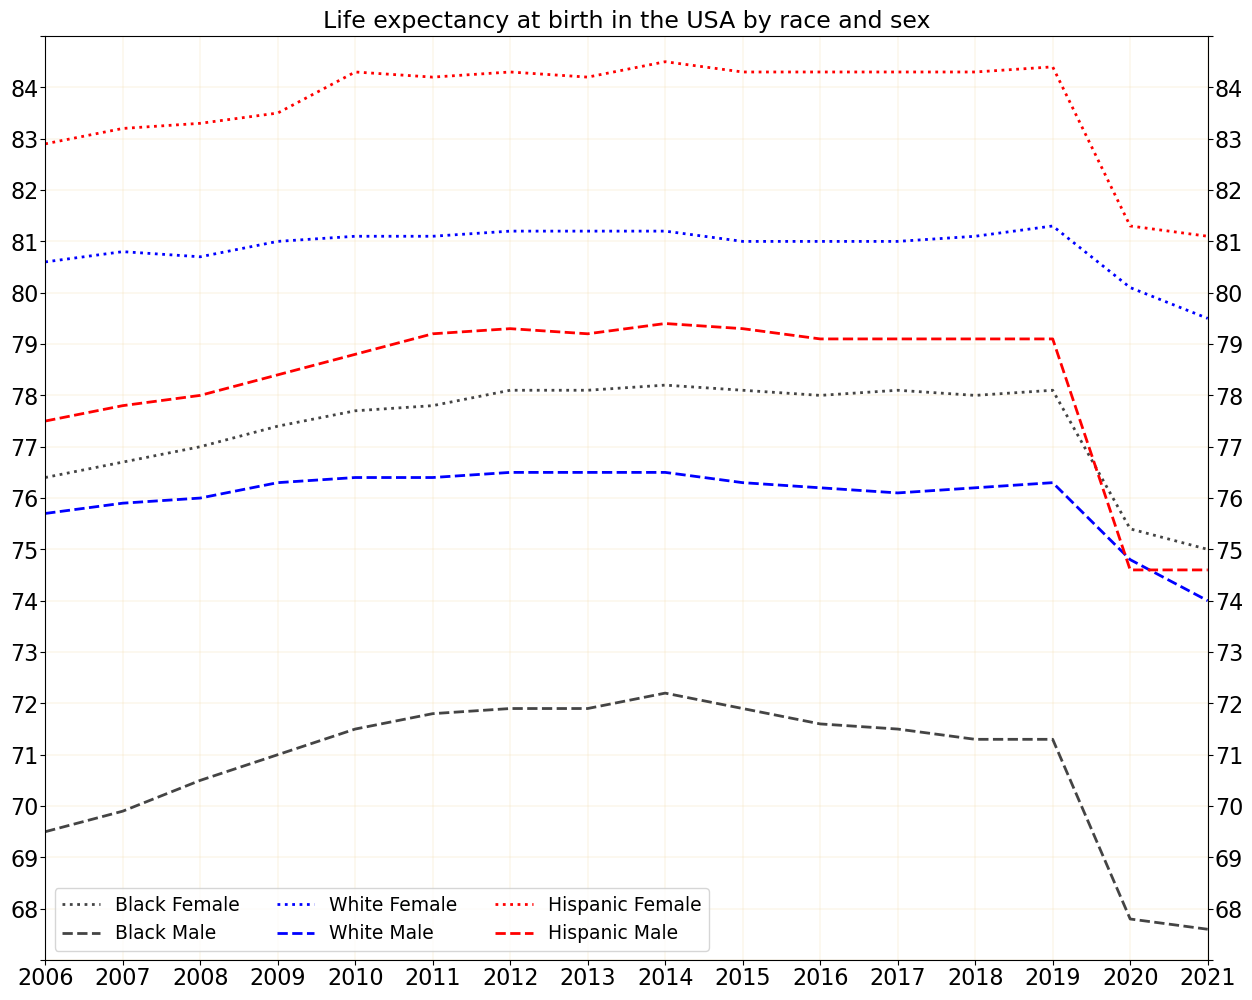

In [13]:
create_chart(df.loc[['Black_female', 'Black_male', 'White_female', 'White_male', 'Hispanic_female', 'Hispanic_male']],
             file_name='Life expectancy in USA by race -male and female', ncol=3, lang=LANG)

min value: 67.6
max value: 84.5


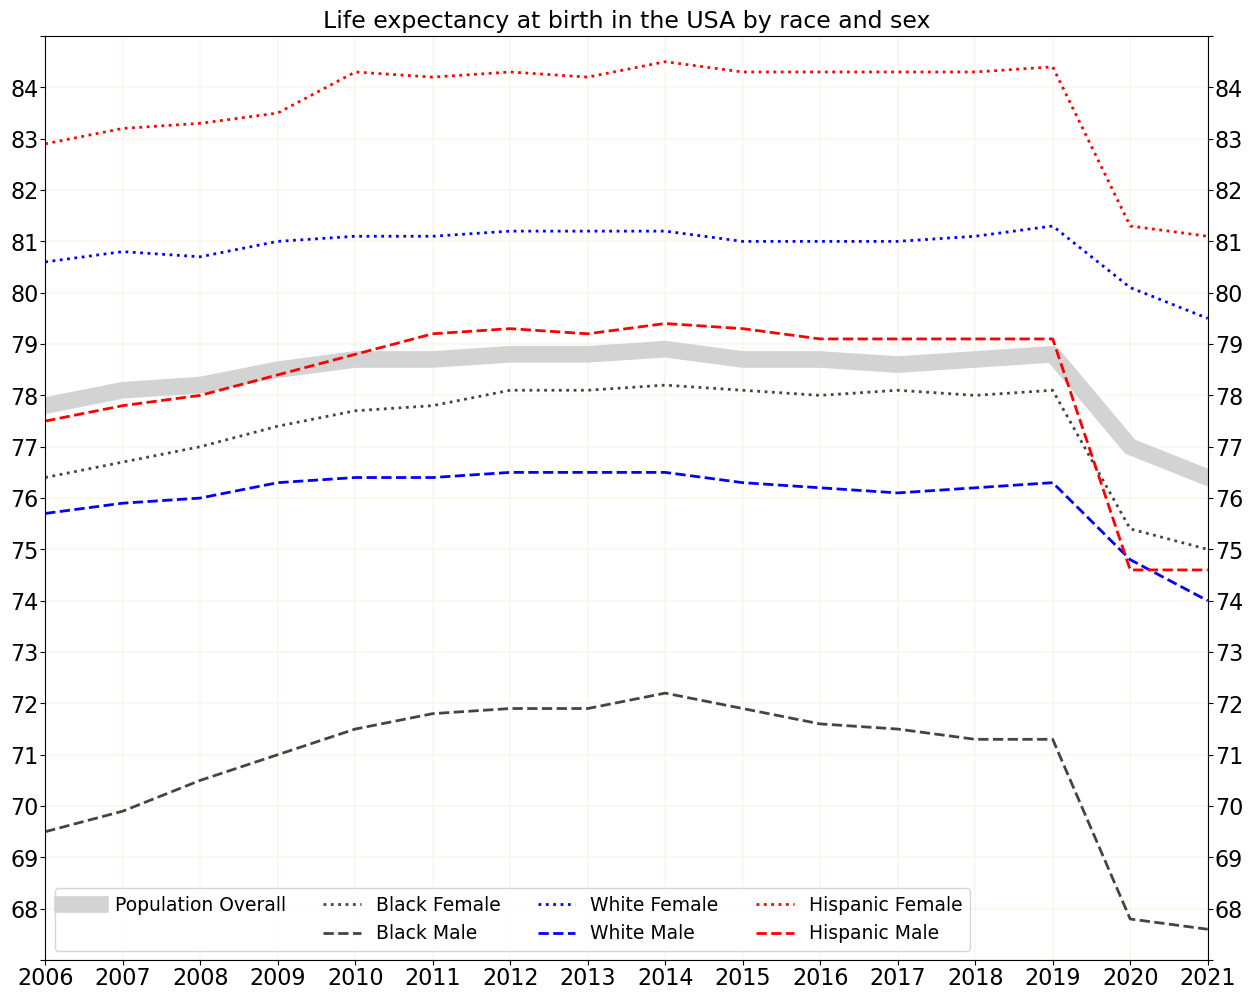

In [14]:
create_chart(df.loc[['Population_all', 'Population_male', 'Black_female', 'Black_male', 'White_female', 'White_male', 'Hispanic_female', 'Hispanic_male']],
             file_name='Life expectancy in USA by race -male and female (2)', lang=LANG, destination='show')

min value: 4.7
max value: 7.6


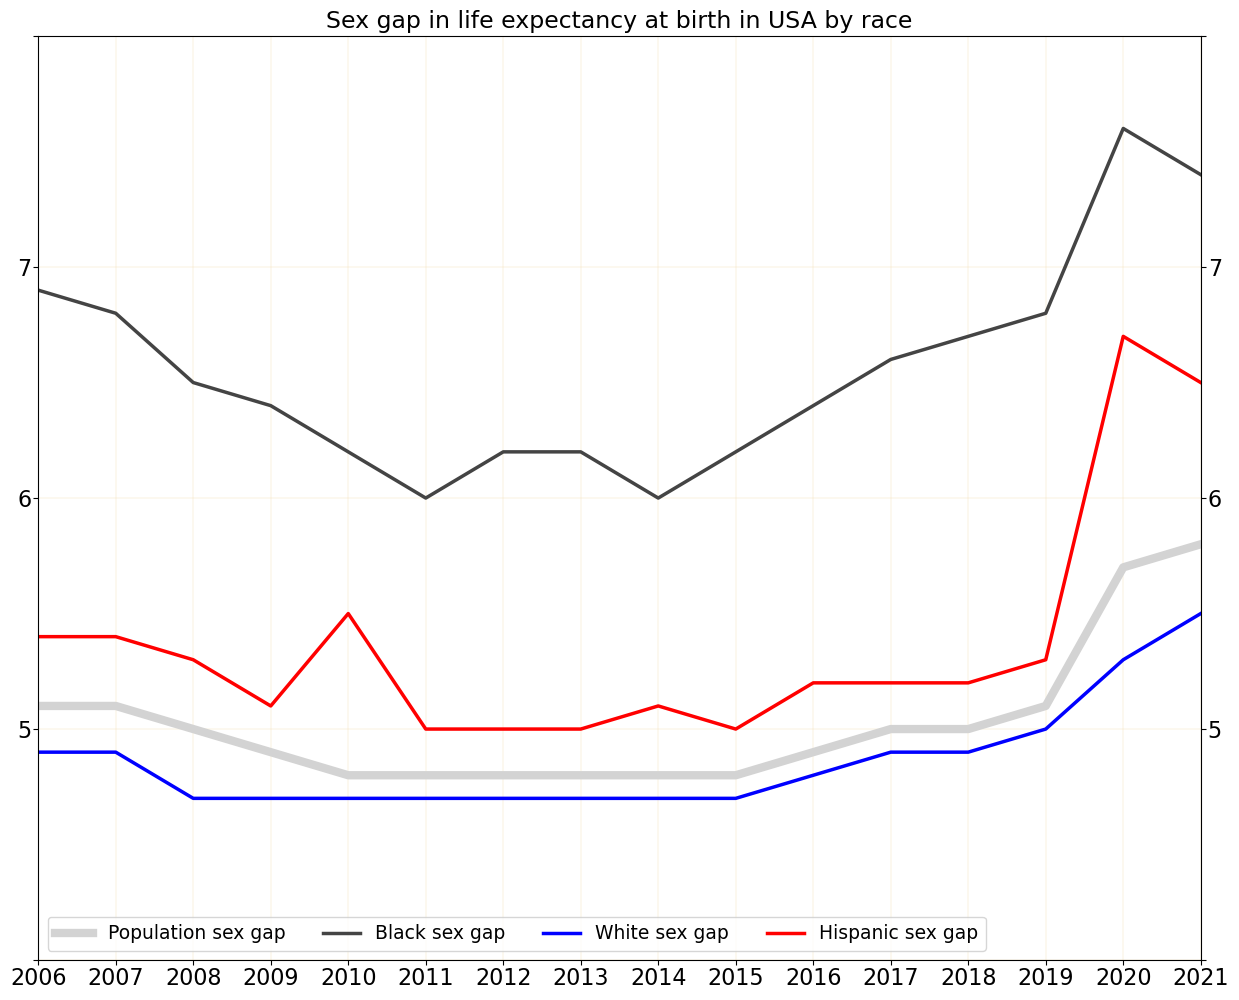

In [15]:
create_chart(df.loc[['Population_fΔm', 'Black_fΔm', 'White_fΔm', 'Hispanic_fΔm']],
             title_en='Sex gap in life expectancy at birth in USA by race',
             title_ru='Разница между полами в ожидаемой при рождении продолжительность жизни в США в зависимости от расы',
             file_name='Life expectancy in USA by race -sex gap', ncol=2 if LANG=='ru' else 4, lang=LANG, destination='show')

<br>
<br>
<br>

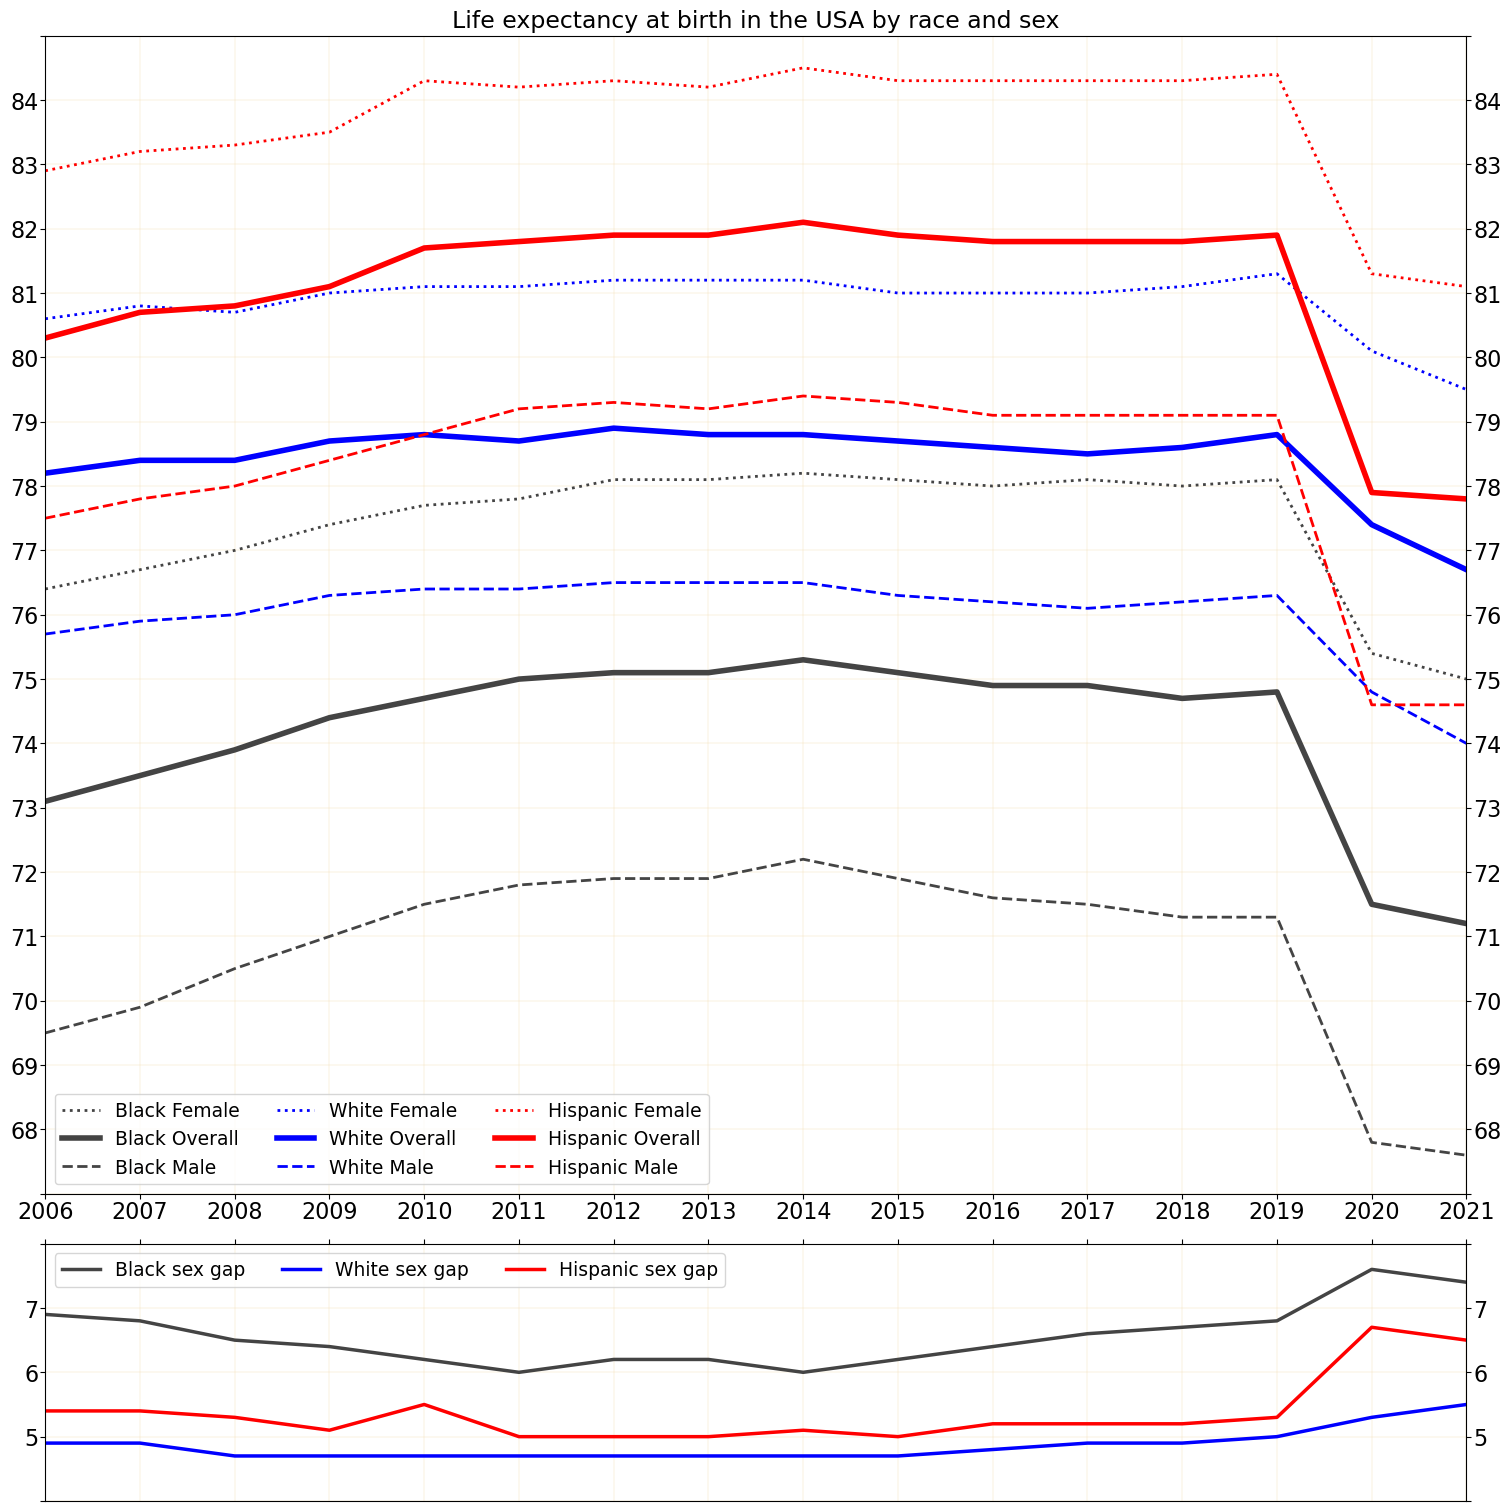

In [17]:
def create_chart_with_difference(df1, df2, lang=LANG, dd_display=dd_display,
                 title_en='Life expectancy at birth in the USA by race and sex',
                 title_ru='Ожидаемая при рождении продолжительность жизни в США в зависимости от расы и пола',
                 destination=DESTINATION_OUTPUT, file_name=''
                ):
    
    plt.rcParams['figure.figsize'] = (16, 16) if lang=='ru' else (15, 15)
    
    year_min = df1.columns[0]
    year_max = df1.columns[-1]
    
    ylim_min_1 = math.floor(df1.min().min())
    ylim_max_1 = math.ceil (df1.max().max())
    ylim_min_2 = math.floor(df2.min().min())
    ylim_max_2 = math.ceil (df2.max().max())
    
    # set chart areas, their locations, sizes and appearances
    fig, (ax1, ax2) = plt.subplots(nrows=2,
                                   gridspec_kw={'height_ratios': [ylim_max_1 - ylim_min_1,
                                                                  ylim_max_2 - ylim_min_2]},
                                   constrained_layout=True)
    
    # set where ticks and labels will be shown around charts
    ax1.tick_params(axis='x', which='both', top=False, bottom=True, labeltop=False, labelbottom=True, pad=1.5)
    ax1.tick_params(axis='y', which='both', left=True, right=True, labelleft=True, labelright=True, pad=1.5)
    ax2.tick_params(axis='x', which='both', top=True, bottom=False, labeltop=False, labelbottom=False, pad=1.5)
    ax2.tick_params(axis='y', which='both', left=True, right=True, labelleft=True, labelright=True, pad=1.5)

    # set limits of chart axes
    ax1.set_xlim(year_min, year_max)
    ax2.set_xlim(year_min, year_max)
    ax1.set_ylim(ylim_min_1, ylim_max_1)
    ax2.set_ylim(ylim_min_2, ylim_max_2)

    # set ticks and labels
    labels_x = range(year_min, year_max+1)
    ax1.set_xticks(labels_x)
    ax2.set_xticks(labels_x)
    ax1.set_xticklabels(labels_x, fontsize=16, rotation='horizontal')
    
    
    labels_y_1 = tuple(range(ylim_min_1, ylim_max_1+1))
    ax1.set_yticks(labels_y_1)
    ax1.set_yticklabels(('',)  + tuple(labels_y_1)[1:-1] + ('',), fontsize=16)
    labels_y_2 = tuple(range(ylim_min_2, ylim_max_2+1))
    ax2.set_yticks(labels_y_2)
    ax2.set_yticklabels(('',)  + tuple(labels_y_2)[1:-1] + ('',), fontsize=16)

    # settings grids
    ax1.grid(color='wheat', linewidth=0.3)
    ax2.grid(color='wheat', linewidth=0.3)

    # set title
    ax1.set_title(label=title_ru if lang=='ru' else title_en, fontsize=17)
    
    # plot chart 1
    for gr in df1.index.to_list():
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        ax1.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style, linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha)
    
    # plot chart 2
    for gr in df2.index.to_list():
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        ax2.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style, linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha)
    
    ax1.legend(loc='lower left', fontsize=13.5, ncol=3)
    ax2.legend(loc='upper left', fontsize=13.5, ncol=2 if lang=='ru' else 4)
    
    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()

df1 = df.loc[['Black_female', 'Black_all', 'Black_male',
              'White_female', 'White_all', 'White_male',
              'Hispanic_female', 'Hispanic_all', 'Hispanic_male']]

df2 = df.loc[['Black_fΔm', 'White_fΔm', 'Hispanic_fΔm']]
create_chart_with_difference(df1, df2,
             file_name='Life expectancy in USA by race -sex gap', lang=LANG)